In [1]:
import os
import sys

# TODO: Remove this hackish way of loading parent's dir modules
sys.path.insert(0, os.path.abspath('..'))

# Velocity vectors visualization

In [2]:
from pathlib import Path
import numpy as np
from IO import load_bboxes
from IO import load_num_optical_flow_frames
from optical_flow import flow_sizes_constants
from util import images_size

dataset_path = Path('/datasets/soccernet')
num_optical_flow_frames = load_num_optical_flow_frames(dataset_path)

match_path = dataset_path.joinpath('england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley')
velocity_results = np.load(match_path.joinpath('velocity_results.npy'), allow_pickle=True).item()

half = 0
half_match_path = match_path.joinpath(f'{half + 1}_HQ')

num_rgb_frames = len(load_bboxes(match_path, half))

optical_flow_indices = np.ceil(np.linspace(num_optical_flow_frames[match_path][half] / num_rgb_frames,
                                           num_optical_flow_frames[match_path][half],
                                           num=num_rgb_frames)).astype(int) - 1

frames_path = half_match_path.joinpath('frames')

rgb_shape = images_size(frames_path)
flow_sizes = flow_sizes_constants(rgb_shape)

## Fixed regions mask

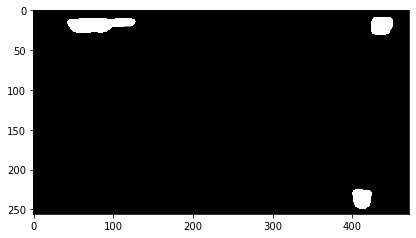

In [3]:
import matplotlib.pyplot as plt
from velocity import calculate_fixed_regions_mask
   
fixed_regions_mask = calculate_fixed_regions_mask(half_match_path, optical_flow_indices, num_rgb_frames)

fig = plt.figure(figsize=(7.5, 3.75))
plt.imshow(fixed_regions_mask, cmap=plt.get_cmap('gray'),vmin=0,vmax=1)
# plt.savefig(f'fixed_regions_mask.png', format='png', dpi=150, bbox_inches='tight')
plt.show()

## Fixed regions patches

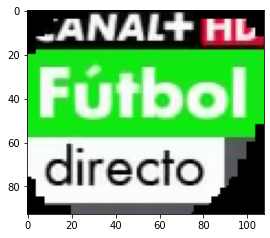

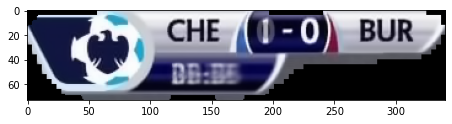

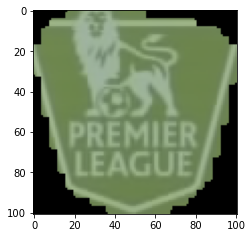

In [4]:
from velocity import segment_fixed_regions
from optical_flow import flow_sizes_constants
from util import images_size
    
fixed_regions = segment_fixed_regions(half_match_path, optical_flow_indices, num_rgb_frames, flow_sizes)

for i in range(len(fixed_regions)):
    fig = plt.figure(figsize=(7.5, 3.75))
    plt.imshow(fixed_regions[i].patch)
    plt.show()

## Velocity vectors

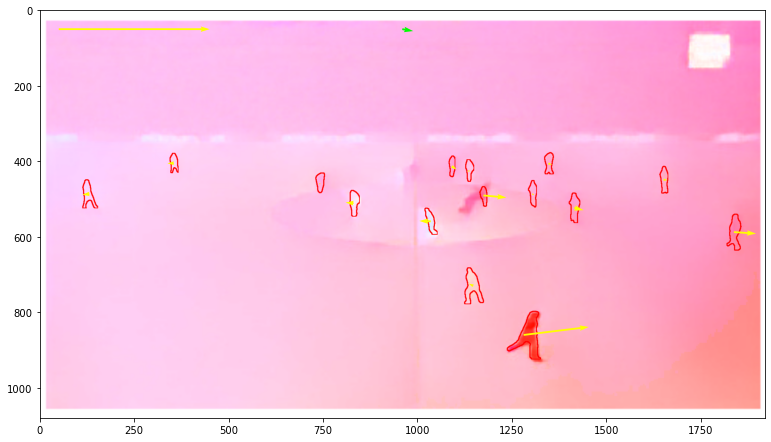

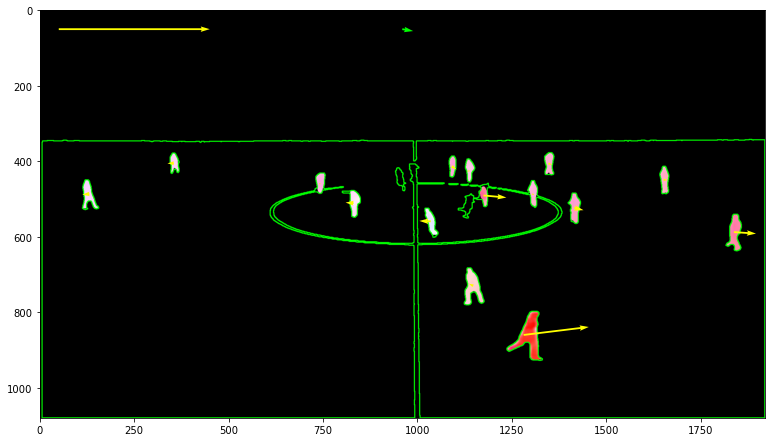

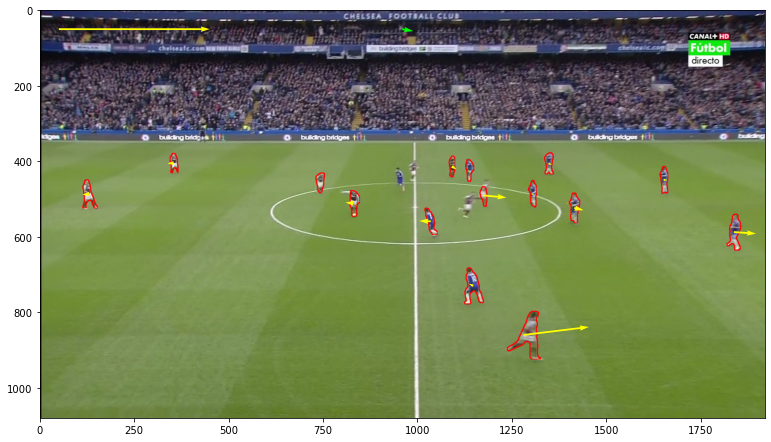

In [5]:
import cv2
import flowiz
import matplotlib as mpl
from skimage import io
from skimage.transform import resize

from IO import load_flow
from optical_flow import add_missing_borders
from regions import draw_mask
from velocity import get_segmented_people
from plots import draw_velocity_vectors
from plots import flow_colormap
from plots import plot_flow_and_masked_flow
from plots import plot_masked_flow_and_rgb
from regions import get_patch

segmentation_results_fpath = match_path.joinpath(f'segmentation_results_{half + 1}_HQ.npy')
semantic_seg = np.load(segmentation_results_fpath, allow_pickle=True)
    
for idx in range(1):
    segmented_people = get_segmented_people(semantic_seg[idx])
    if len(segmented_people) == 0:
        continue

    rgb_frame_path = frames_path.joinpath(f'{idx + 1:05}.jpg')
    rgb = io.imread(rgb_frame_path)

    flow = load_flow(half_match_path, optical_flow_indices[idx])
    flow = add_missing_borders(flow, flow_sizes)
    flow = resize(flow, rgb_shape, anti_aliasing=False, preserve_range=True)
    flow_rgb = flowiz.convert_from_flow(flow, 'rgb')
    masked_flow_rgb = flow_rgb.copy()

    all_masks = np.zeros(rgb_shape, dtype=np.uint8)

    bb_centroids = []
    for bb, mask_cnts in segmented_people:
        draw_mask(all_masks, bb, mask_cnts)
        bb_centroids.append((bb[2:] + bb[:2]) / 2)

        patch = get_patch(rgb, bb, copy=False)
        cv2.drawContours(patch, mask_cnts, -1, (255, 0, 0), 2)

        patch = get_patch(flow_rgb, bb, copy=False)
        cv2.drawContours(patch, mask_cnts, -1, (255, 0, 0), 2)

    xy = np.asarray(bb_centroids)
    velocity = velocity_results[half][idx]['velocity']
    field_vector = velocity_results[half][idx]['field_vector']
    masked_flow_rgb = cv2.bitwise_and(masked_flow_rgb, masked_flow_rgb, mask=all_masks)
    cv2.drawContours(masked_flow_rgb, velocity_results[half][idx]['field_mask'], -1, (0, 255, 0), 2)

    fig = plt.figure(figsize=(15, 7.5))
    plt.imshow(flow_rgb)
    draw_velocity_vectors(plt, xy, velocity, field_vector, rgb_shape[1])
    plt.show()

    fig = plt.figure(figsize=(15, 7.5))
    plt.imshow(masked_flow_rgb)
    draw_velocity_vectors(plt, xy, velocity, field_vector, rgb_shape[1])
    plt.show()

    fig = plt.figure(figsize=(15, 7.5))
    plt.imshow(rgb)
    draw_velocity_vectors(plt, xy, velocity, field_vector, rgb_shape[1])
    plt.show()

    # fig, ax = plot_flow_and_masked_flow(flow_rgb, masked_flow_rgb, xy, velocity, field_vector, f'{idx + 1:05}')
    # plt.savefig(f'flow-masked_flow_{idx + 1:05}.png', format='png', dpi=150, bbox_inches='tight')
    # plt.show()

    # fig, ax = plot_masked_flow_and_rgb(masked_flow_rgb, rgb, xy, velocity, field_vector, f'{idx + 1:05}')
    # plt.savefig(f'masked_flow-frame_{idx + 1:05}.png', format='png', dpi=150, bbox_inches='tight')
    # plt.show()

    break